In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [8]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

In [9]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
df[numerical_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


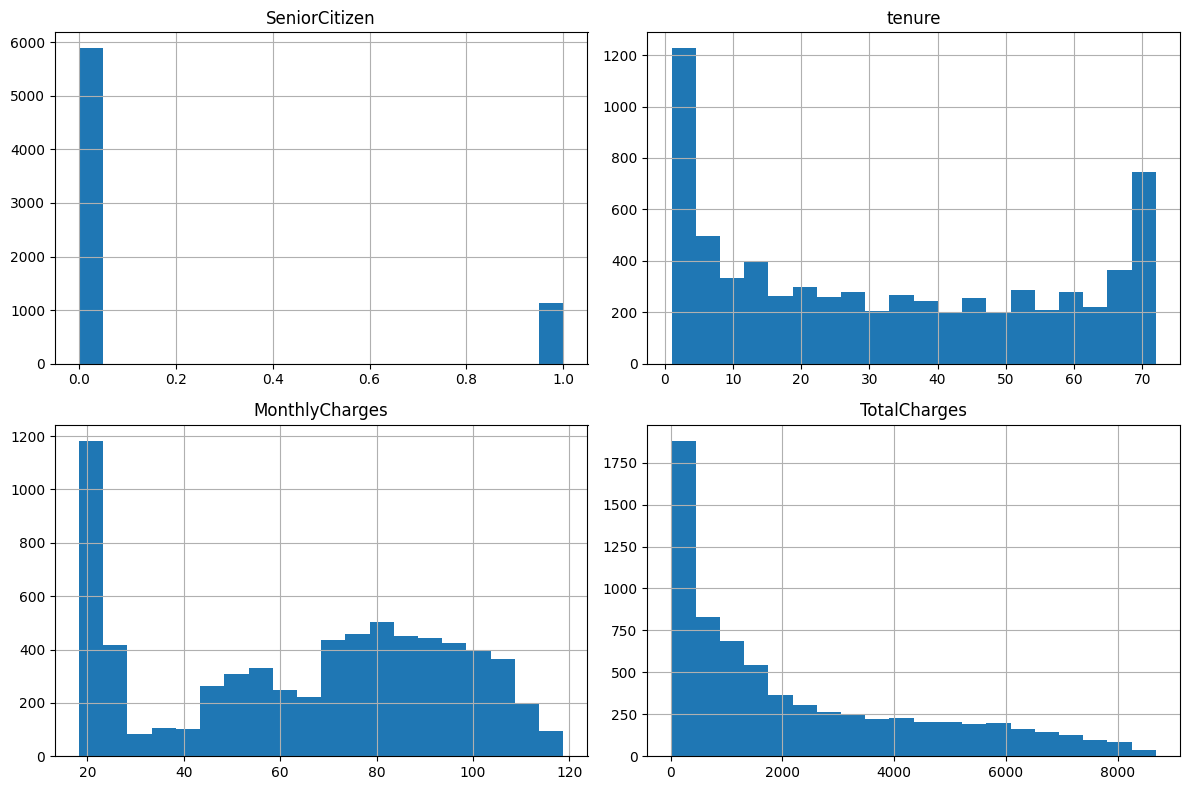

In [11]:
df[numerical_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

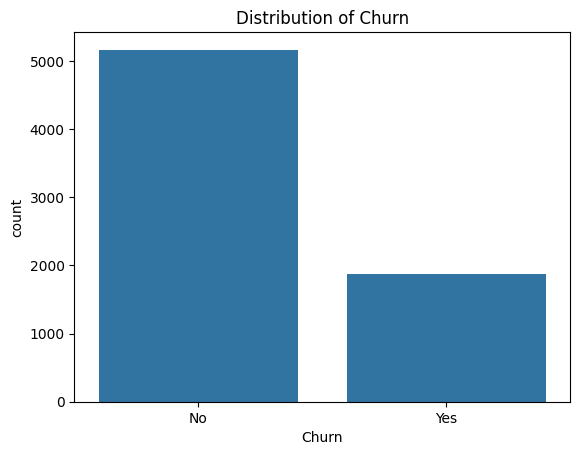

In [12]:
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Churn")
plt.show()

In [13]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


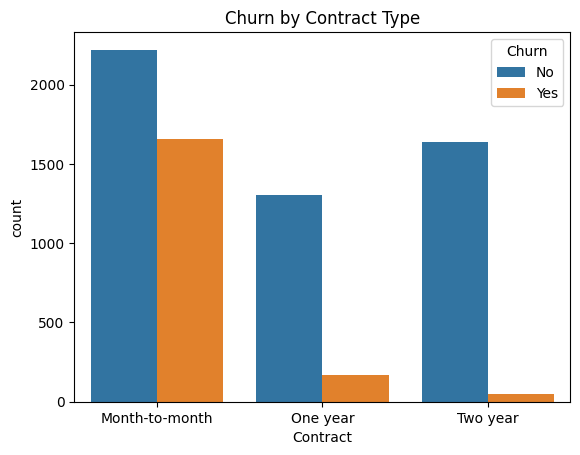

In [14]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=0)
plt.show()

In [15]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


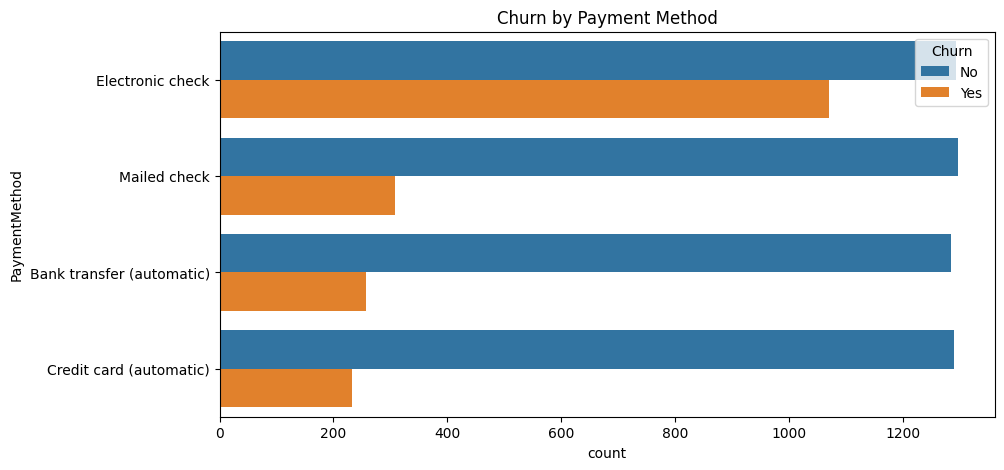

In [16]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.show()

In [17]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


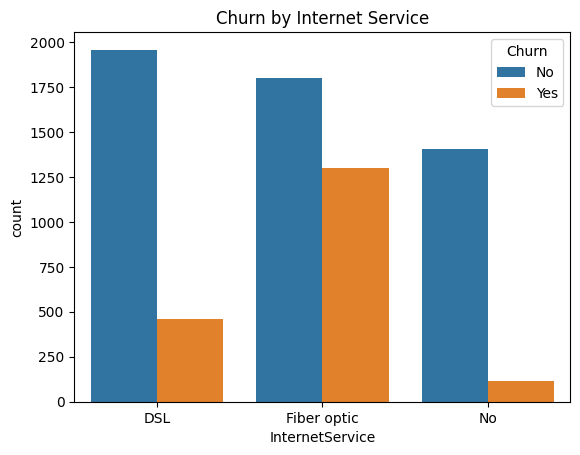

In [18]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

In [19]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


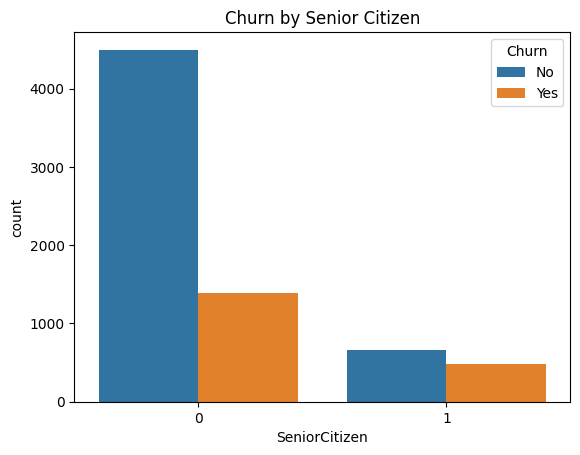

In [20]:
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen")
plt.show()

In [23]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


In [24]:
pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


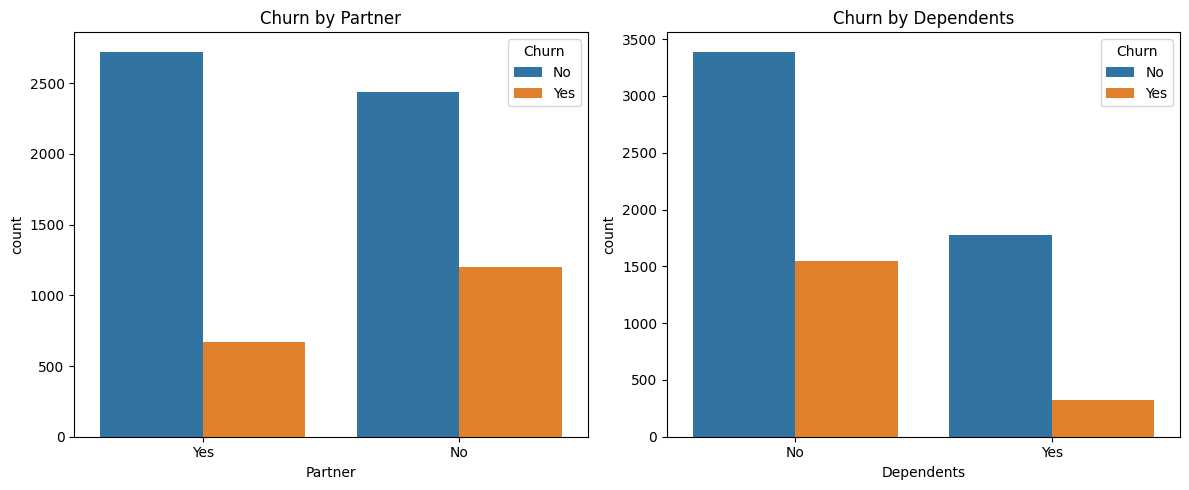

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Partner", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by Partner")

sns.countplot(data=df, x="Dependents", hue="Churn", ax=axes[1])
axes[1].set_title("Churn by Dependents")

plt.tight_layout()
plt.show()

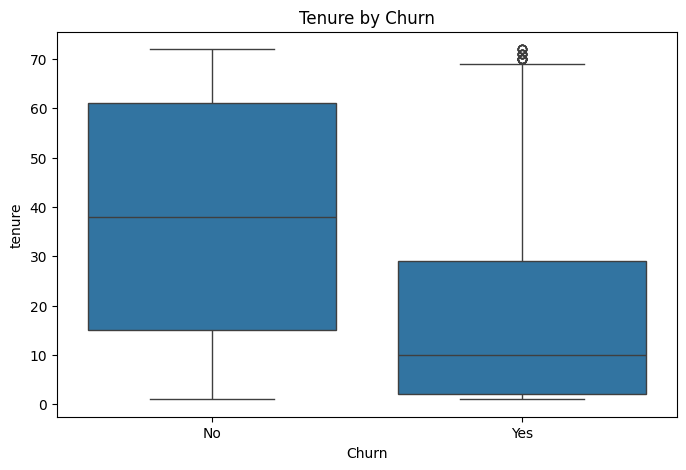

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.show()

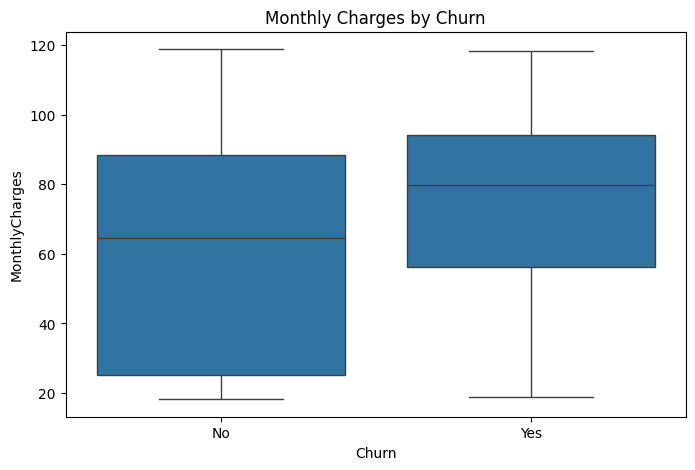

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

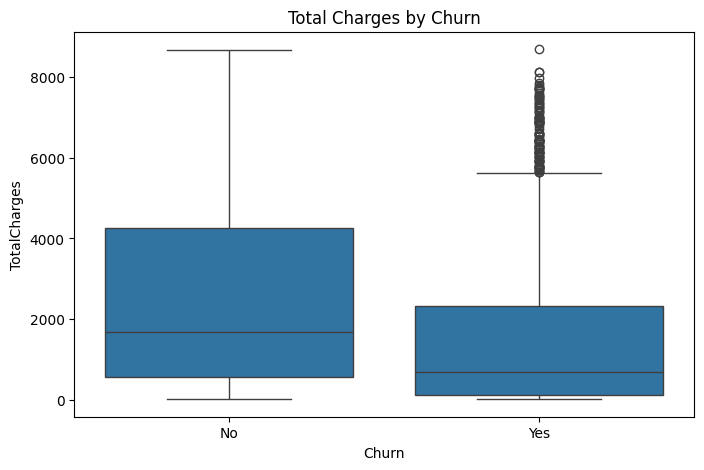

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn")
plt.show()

## Key EDA Insights

1. Customers with month-to-month contracts show the highest churn rate, while two-year contracts show the lowest.
2. Customers using electronic check have a much higher churn rate than customers using other payment methods.
3. Fiber optic customers show a surprisingly high churn rate compared to DSL and customers without internet service.
4. Senior citizens churn more frequently than non-senior customers.
5. Customers who churn tend to have lower tenure, higher monthly charges, and lower total charges.

## SQL Validation of Key Findings

The SQL exploration confirmed the main patterns found during the Python EDA:

- Customers with month-to-month contracts have the highest churn rate.
- Customers using electronic check show the highest churn rate among payment methods.
- Fiber optic customers have a substantially higher churn rate than DSL or non-internet customers.
- Customers who churn have lower average tenure and higher average monthly charges.

These findings suggest that contract type, payment method, internet service, tenure, and monthly charges may be important predictors of churn.